### 7. (a) Modify your CNN to include batch normalization and dropout. 

C:\Users\gayat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.8549 - loss: 0.4741 - val_accuracy: 0.9840 - val_loss: 0.0529
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9702 - loss: 0.0975 - val_accuracy: 0.9882 - val_loss: 0.0428
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9789 - loss: 0.0708 - val_accuracy: 0.9885 - val_loss: 0.0396
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9827 - loss: 0.0582 - val_accuracy: 0.9897 - val_loss: 0.0317
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9831 - loss: 0.0539 - val_accuracy: 0.9885 - val_loss: 0.0363
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9841 - loss: 0.0507 - val_accuracy: 0.9898 - val_loss: 0.0349
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9900 - val_loss: 0.0322
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9872 - loss: 0.0415 - 

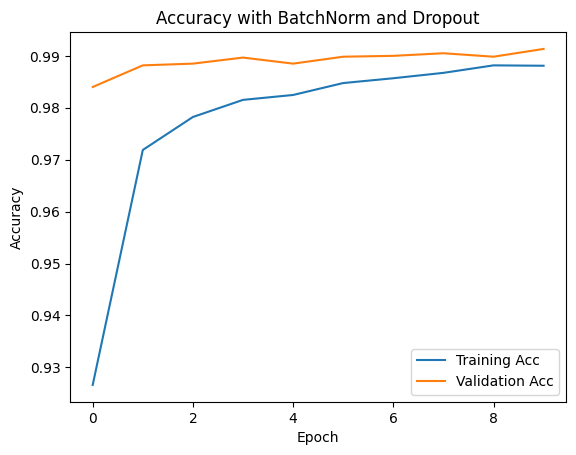

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load and preprocess MNIST dataset
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN input: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 2. Define CNN model with Batch Normalization and Dropout
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# 5. Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# 6. Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy with BatchNorm and Dropout')
plt.legend()
plt.show()


   ### 7 (b) Modify your CNN architecture to include residual connections (similar to ResNet). 

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - accuracy: 0.9024 - loss: 0.3321 - val_accuracy: 0.9807 - val_loss: 0.0685
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9845 - loss: 0.0513 - val_accuracy: 0.9880 - val_loss: 0.0434
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9858 - val_loss: 0.0498
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.9855 - val_loss: 0.0531
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.9952 - loss: 0.0148 - val_accuracy: 0.9868 - val_loss: 0.0504
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 61s 72ms/step - accuracy: 0.9950 - loss: 0.0141 - val_accuracy: 0.9883 - val_loss: 0.0549
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 60s 71ms/step - accuracy: 0.9961 - loss: 0.0114 - val_accuracy: 0.9887 - val_loss: 0.0452
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 69ms/step - accuracy: 0.9967 - loss: 0.0099 - 

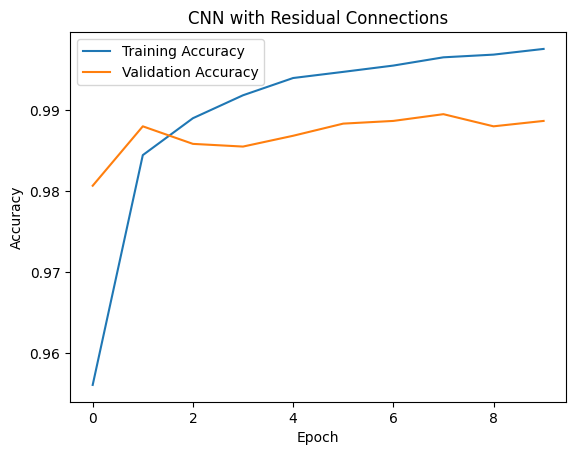

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load and preprocess MNIST dataset
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize and reshape
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 2. Define a residual block
def residual_block(x, filters):
    shortcut = x  # Save input as shortcut

    # Convolution layer 1
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Convolution layer 2
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Add shortcut to the output
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# 3. Build the CNN with residual connection
inputs = tf.keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)

# Residual block
x = residual_block(x, 32)

x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(10, activation='softmax')(x)

# Model
model = models.Model(inputs=inputs, outputs=x)

# 4. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# 6. Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# 7. Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN with Residual Connections')
plt.legend()
plt.show()
